In [15]:
import os

print(os.environ['PYTHONHASHSEED'])

0


In [16]:
from gerrychain import Graph, Partition, MarkovChain, Election, updaters, constraints, accept
from gerrychain.proposals import recom
from gerrychain.constraints import contiguous
from gerrychain.tree import bipartition_tree
from functools import partial
import pandas as pd

In [17]:
# Load the graph in from the provided json file
graph = Graph.from_json("./PA_VTDs.json")


# Set up updaters
my_updaters = {
    "population": updaters.Tally("TOT_POP", alias="population"),
    "white_population": updaters.Tally("WHITE_POP", alias="white_population"),
    "black_population": updaters.Tally("BLACK_POP", alias="black_population"),
    "hispanic_population": updaters.Tally("HISP_POP", alias="hispanic_population"),
    "asian_population": updaters.Tally("ASIAN_POP", alias="asian_population"),
    "native_population": updaters.Tally("NATIVE_POP", alias="native_population"),
    "cut_edges": updaters.cut_edges,
    # election to be added
}

# Set up election updater
elections = {
    "SEN10": Election("SEN10", {"Democratic": "SEN10D", "Republican": "SEN10R"}),
    "SEN12": Election("SEN12", {"Democratic": "USS12D", "Republican": "USS12R"}),
    "SEN16": Election("SEN16", {"Democratic": "T16SEND", "Republican": "T16SENR"}),
    "PRES12": Election("PRES12", {"Democratic": "PRES12D", "Republican": "PRES12R"}),
    "PRES16": Election("PRES16", {"Democratic": "T16PRESD", "Republican": "T16PRESR"})
}

my_updaters.update(elections)

# Set up the initial partition object
initial_partition = Partition(
    graph,
    assignment = "2011_PLA_1",
    updaters = my_updaters
)

ideal_population = sum(initial_partition["population"].values()) / len(initial_partition)
# print(f"ideal population: {ideal_population}")
print(list(initial_partition.updaters.keys()))
# create new function from the recom with our given arguments
proposal = partial(
    recom,
    pop_col="TOT_POP",
    pop_target=ideal_population,
    epsilon=0.01,
    node_repeats=2,
    method = partial(
        bipartition_tree,
        max_attempts=100,
        allow_pair_reselection=True 
    )
)

['cut_edges', 'population', 'white_population', 'black_population', 'hispanic_population', 'asian_population', 'native_population', 'SEN10', 'SEN12', 'SEN16', 'PRES12', 'PRES16']


In [18]:
# add party seats
def party_seats_entrys(partition):
    election_results = partition["PRES12"]

    # find which candidate won which district 
    dem_districts = []
    repub_districts = []
    districts = partition["population"].keys()
    for district in districts:
        if election_results.won("Democratic", district):
            dem_districts.append(district)
        else:
            repub_districts.append(district)

    return pd.DataFrame([{
        "Republican Seats": election_results.seats("Republican"),
        "Democrat Seats": election_results.seats("Democratic"),
        "Republican Districts": repub_districts,
        "Democrat Districts": dem_districts
    }])

In [19]:
# add population
def population_entrys(partition):

    population_keys = ["population", "white_population", "black_population", 
                       "hispanic_population", "asian_population", "native_population"]

    df = pd.DataFrame()
    for key in population_keys:
        df[key] = [partition[key]]
        
    return df

In [20]:
# find perfered candidate
def perfered_candidate(minority):
    return "Democrat"

In [21]:
def create_row_entry(partition):
    seats = party_seats_entrys(partition) 
    populations = population_entrys(partition)
    
    return pd.concat([seats, populations], axis=1)
    

In [23]:
ensemble = []

BURN_IN = 500           # discard first 1000 steps for randomization
THINNING = 15           # every 10th plan
TARGET_PLANS = 1000      # plans in final ensemble

total_steps = BURN_IN + (THINNING * TARGET_PLANS)

chain = MarkovChain(
    proposal=proposal,
    constraints=[contiguous],
    accept=accept.always_accept,
    initial_state=initial_partition,
    total_steps=total_steps
)

df = pd.DataFrame()

step = 0
for partition in chain.with_progress_bar():
    step+=1
    
    if step < BURN_IN:
        continue
    
    if (step - BURN_IN) % THINNING == 0:
        ensemble.append(partition)
        row_of_data = create_row_entry(partition)
        row_of_data.index = [f"Plan {step}"]
        df = pd.concat([df, row_of_data])

    if len(ensemble) >= TARGET_PLANS:
        break

print(f"Collected {len(ensemble)} plans")  


  0%|          | 0/15500 [00:00<?, ?it/s]

Collected 1000 plans


In [35]:
partition = initial_partition

# normalize weights so they sum to 1 across elections
election_weights = {
    "PRES16": 1.0,
    "SEN16":  1.0,
    "PRES12": 0.5,
    "SEN12":  0.5,
    "SEN10":  0.25
}
total_weight = sum(election_weights.values())  # normalize
election_weights = {k: v / total_weight for k, v in election_weights.items()}

# calculate s(D) per district
district_scores = {district: 0 for district in partition["population"].keys()}

for name, election in elections.items():
    election_results = partition[name]
    w = election_weights[name]
    
    # placeholder until PyEI is run
    candidate_of_choice_confidence = 0.85
    group_member = 1 # 0.5 
    
    weight = w * candidate_of_choice_confidence * group_member

    for district in partition["population"].keys():
        if election_results.won("Democratic", district):
            district_scores[district] += weight

# check threshold per district
THRESHOLD = 0.6
for district, score in district_scores.items():
    print(f"District {district}: s(D)={score:.3f}, effective={score >= THRESHOLD}")

District 3: s(D)=0.000, effective=False
District 10: s(D)=0.000, effective=False
District 9: s(D)=0.000, effective=False
District 5: s(D)=0.000, effective=False
District 15: s(D)=0.131, effective=False
District 6: s(D)=0.392, effective=False
District 11: s(D)=0.000, effective=False
District 8: s(D)=0.131, effective=False
District 4: s(D)=0.000, effective=False
District 18: s(D)=0.000, effective=False
District 12: s(D)=0.000, effective=False
District 17: s(D)=0.327, effective=False
District 7: s(D)=0.392, effective=False
District 16: s(D)=0.000, effective=False
District 14: s(D)=0.850, effective=True
District 13: s(D)=0.850, effective=True
District 2: s(D)=0.850, effective=True
District 1: s(D)=0.850, effective=True


In [ ]:
print(df)

df.to_csv("ensemble_results.csv", index=True)

          Republican Seats  Democrat Seats  \
Plan 10                 12               6   
Plan 11                 12               6   
Plan 12                 11               7   
Plan 13                 11               7   
Plan 14                 11               7   
...                    ...             ...   
Plan 255                 9               9   
Plan 256                 9               9   
Plan 257                 9               9   
Plan 258                 9               9   
Plan 259                10               8   

                               Republican Districts  \
Plan 10   [3, 15, 10, 5, 9, 6, 11, 4, 8, 18, 7, 16]   
Plan 11   [3, 15, 10, 5, 9, 6, 11, 4, 8, 18, 7, 16]   
Plan 12      [3, 15, 10, 5, 9, 6, 11, 4, 8, 18, 16]   
Plan 13      [3, 15, 10, 5, 9, 6, 11, 4, 8, 18, 16]   
Plan 14      [3, 15, 10, 5, 9, 6, 11, 4, 8, 18, 16]   
...                                             ...   
Plan 255           [15, 5, 12, 6, 4, 14, 16, 13, 2]   
Plan 25

   Republican Seats  Democrat Seats  Count
0                 7              11      2
1                 8              10     76
2                 9               9    369
3                10               8    458
4                11               7     89
5                12               6      6


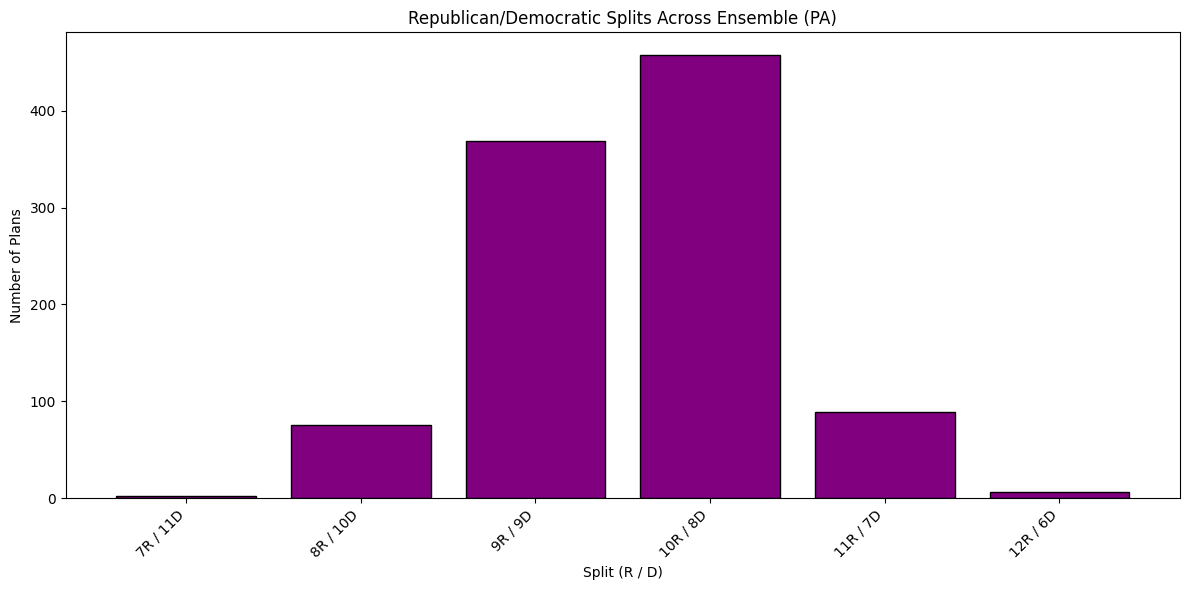

In [26]:
import matplotlib.pyplot as plt

splits_counts = df.groupby(["Republican Seats", "Democrat Seats"]).size().reset_index(name="Count")
print(splits_counts)

splits_counts["Split"] = (
    splits_counts["Republican Seats"].astype(int).astype(str) + "R / " +
    splits_counts["Democrat Seats"].astype(int).astype(str) + "D"
)

splits_counts = splits_counts.sort_values("Republican Seats")

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(splits_counts["Split"], splits_counts["Count"], color="purple", edgecolor="black")

ax.set_xlabel("Split (R / D)")
ax.set_ylabel("Number of Plans")
ax.set_title("Republican/Democratic Splits Across Ensemble (PA)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

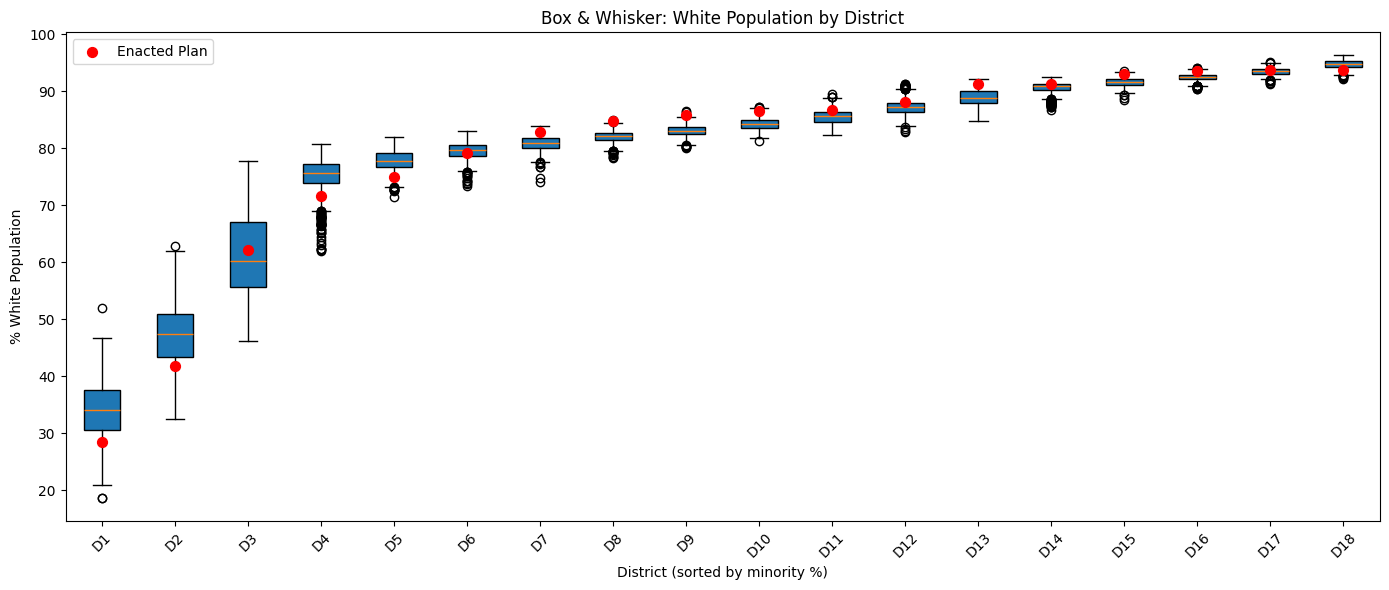

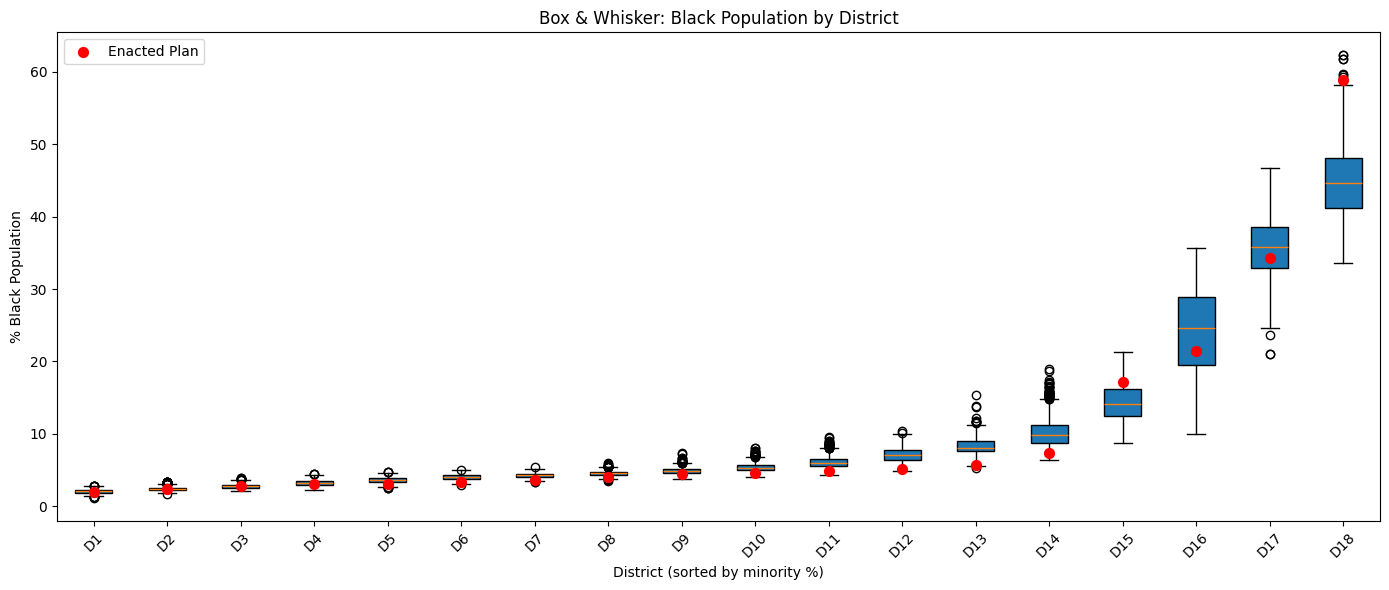

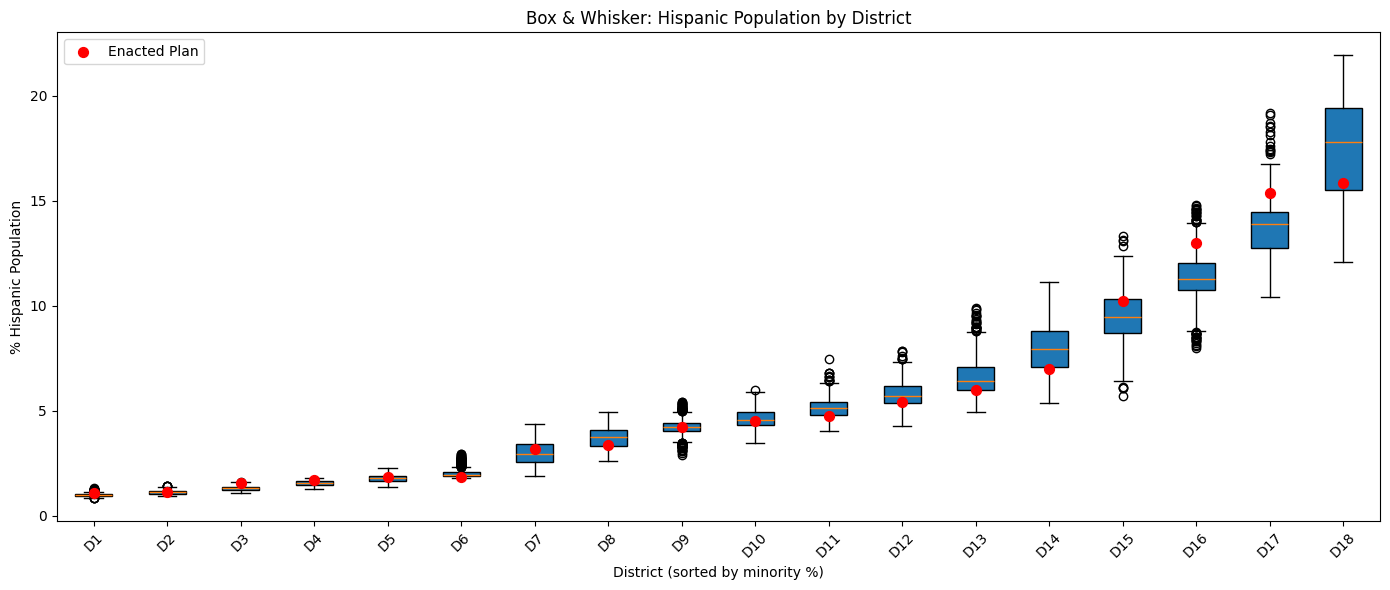

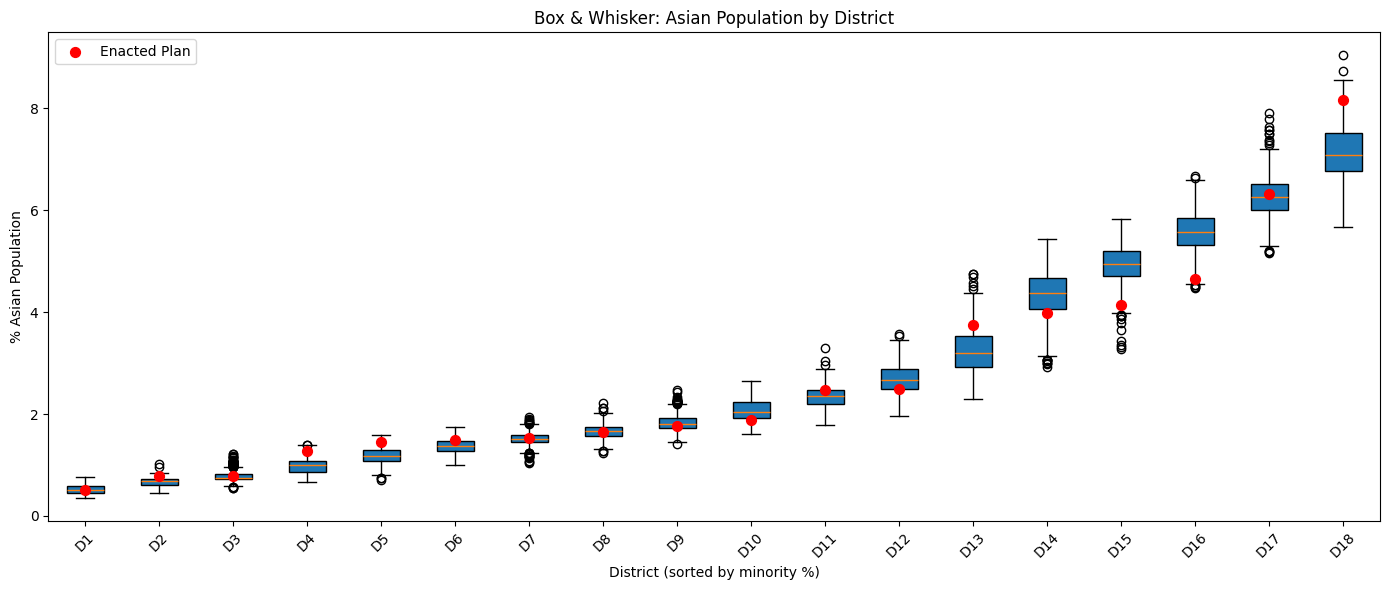

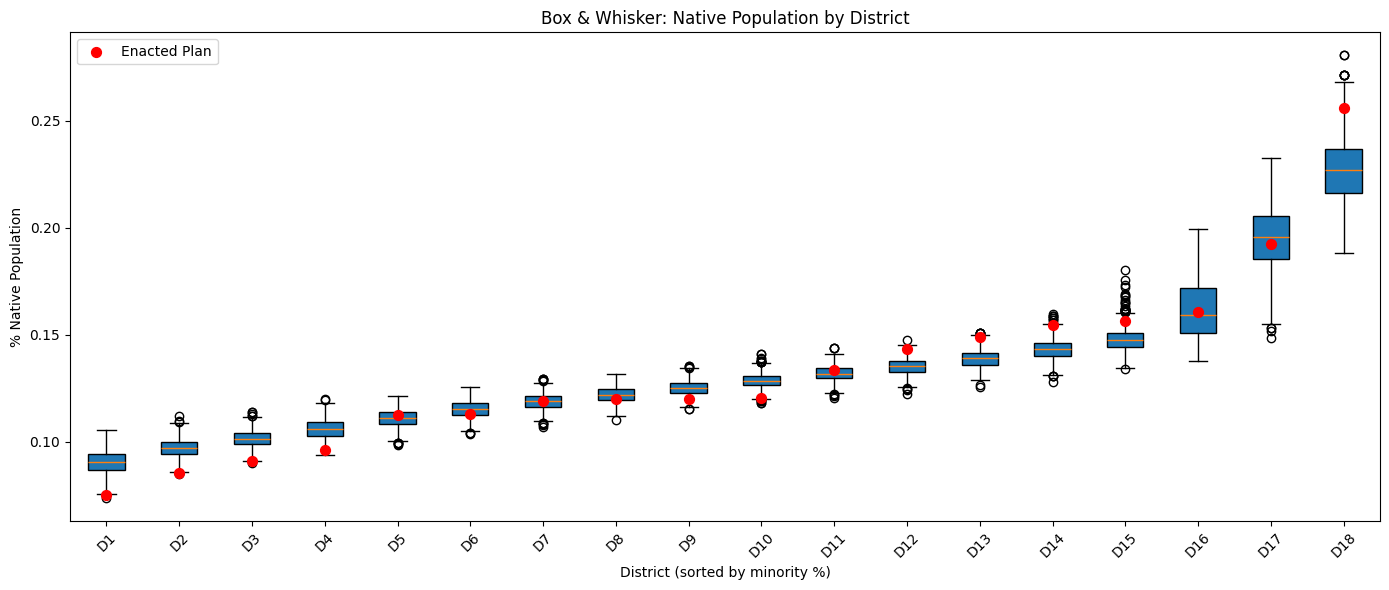

In [27]:
import matplotlib.pyplot as plt

population_keys = ["population", "white_population", "black_population", 
                   "hispanic_population", "asian_population", "native_population"]

num_of_districts = len(ensemble[0]["population"].keys())

# aggregate_minority_data[key][i] = list of minority % for district i across all plans
aggregate_minority_data = {}
for key in population_keys:
    aggregate_minority_data[key] = [[] for _ in range(num_of_districts)]

for partition in ensemble:
    for key in population_keys:
        district_percents = []
        for district in partition["population"].keys():
            total_pop = partition["population"][district]
            minority_pop = partition[key][district]
            percent = (minority_pop / total_pop * 100) if total_pop > 0 else 0
            district_percents.append(percent)
        
        district_percents.sort()
        
        for i, pct in enumerate(district_percents):
            aggregate_minority_data[key][i].append(pct)

# pre-compute enacted plan percentages for each minority group
enacted_percents = {}
for key in population_keys:
    district_percents = []
    for district in initial_partition["population"].keys():
        total_pop = initial_partition["population"][district]
        minority_pop = initial_partition[key][district]
        percent = (minority_pop / total_pop * 100) if total_pop > 0 else 0
        district_percents.append(percent)
    enacted_percents[key] = sorted(district_percents)  # sort to match box plot ordering

# plot box & whisker for each minority group
for key in population_keys:
    if key == "population":
        continue

    fig, ax = plt.subplots(figsize=(14, 6))
    
    ax.boxplot(aggregate_minority_data[key], 
               positions=range(num_of_districts),
               patch_artist=True)
    
    # overlay enacted plan dots
    ax.scatter(
        x=range(num_of_districts),
        y=enacted_percents[key],
        color="red",
        zorder=5,          # draw on top of box plots
        s=50,              # dot size
        label="Enacted Plan"
    )
    
    ax.set_xlabel("District (sorted by minority %)")
    ax.set_ylabel(f"% {key.replace('_', ' ').title()}")
    ax.set_title(f"Box & Whisker: {key.replace('_', ' ').title()} by District")
    ax.set_xticks(range(num_of_districts))
    ax.set_xticklabels([f"D{i+1}" for i in range(num_of_districts)], rotation=45)
    ax.legend()
    
    plt.tight_layout()
    plt.show()

Matched: 8921 / 9255


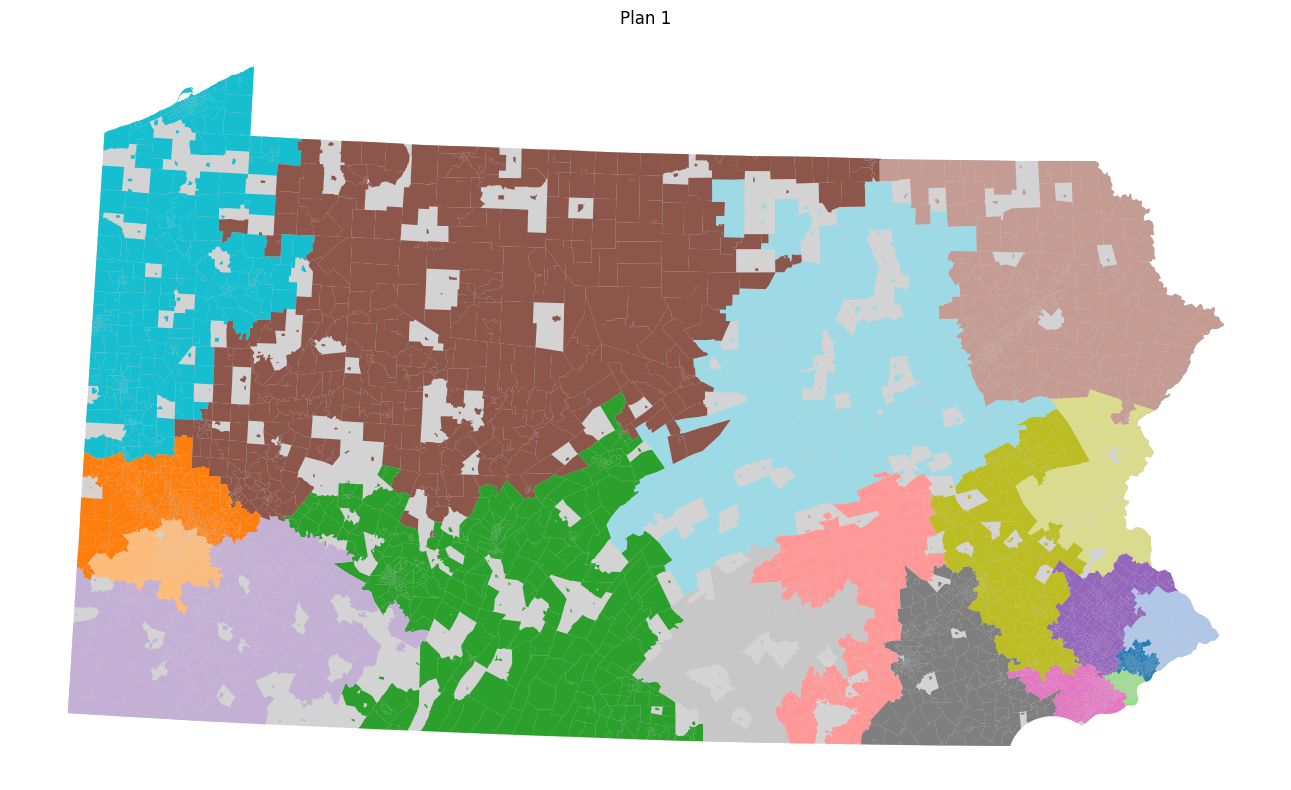

In [33]:
import geopandas as gpd
import matplotlib.pyplot as plt

gdf = gpd.read_file("./PA_shape/PA.shp")

# Same matching approach as before
def geoid_to_key(geoid):
    state = geoid[:2]
    county = geoid[2:5]
    vtd = geoid[5:].lstrip('0') or '0'
    return (state, county, vtd)

id_to_geoid = {node: data["GEOID10"] for node, data in graph.nodes(data=True)}
key_to_geoid = {geoid_to_key(geoid): geoid for geoid in id_to_geoid.values()}

gdf["match_key"] = list(zip(
    gdf["STATEFP10"].astype(str),
    gdf["COUNTYFP10"].astype(str),
    gdf["VTDST10"].astype(str).str.lstrip('0').replace('', '0')
))

gdf["GEOID10_matched"] = gdf["match_key"].map(key_to_geoid)
print(f"Matched: {gdf['GEOID10_matched'].notna().sum()} / {len(gdf)}")

fig, axes = plt.subplots(figsize=(20, 8))

plan = 1

partition = ensemble[plan]

geoid_to_district = {id_to_geoid[node]: district
                        for node, district in partition.assignment.items()}

gdf["district"] = gdf["GEOID10_matched"].map(geoid_to_district)

state_outline = gdf.dissolve()
state_outline.plot(ax=axes, color="lightgray", edgecolor="none")

gdf[gdf["district"].notna()].plot(
    column="district",
    ax=axes,
    cmap="tab20",
    legend=False,
    edgecolor="none",
    linewidth=0
)
axes.set_title(f"Plan {plan}")
axes.axis("off")

    

plt.tight_layout()
plt.show()